# AISO Comprehensive Benchmark

| Part | 실험 | 변수 |
|---|---|---|
| A | **차원 스윕** | K = 2, 5, 10, 20, 30, 50 |
| B | **타입 차원 분리** | N_TYPES = 3,5,8,12,20 (K_search 고정) |
| C | **새 AISO 변형** | Elite Restart / Adaptive M / RepulsionMode |
| D | **예산 스윕** | N_ITER = 10, 20, 50, 100, 200, 500 |
| E | **노이즈 내성** | σ = 0, 1, 2, 5, 10 |
| F | **다봉성 강도** | Rastrigin A = 1, 5, 10, 20, 50 |
| G | **META 히트맵** | (K × Budget) 조건별 홈그라운드 확정 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ── 전역 하이퍼파라미터 ──────────────────────────────────────
N_AGENTS  = 30
N_ITER    = 200
ALPHA     = 0.3
BETA      = 0.1
N_TYPES   = 8       # 기본 타입 차원 (K_search와 분리됨)
N_RUNS    = 5
SEEDS     = [42, 123, 777, 2024, 31415]

PSO_W, PSO_C1, PSO_C2       = 0.729, 1.494, 1.494
FA_BETA0, FA_GAMMA, FA_ALPHA = 1.0, 1.0, 0.2
DE_F, DE_CR                  = 0.8, 0.9

COLORS = {
    'AISO':         '#DD8452',
    'AISO_DecType': '#E74C3C',
    'AISO_Elite':   '#922B21',
    'AISO_AdaptM':  '#641E16',
    'AISO_RepMode': '#FF6B35',
    'AISO_Full':    '#8B0000',
    'PSO':          '#4C72B0',
    'Firefly':      '#C44E52',
    'DE':           '#55A868',
    'Random':       '#8C8C8C',
}
print('설정 완료 — N_TYPES={}, N_AGENTS={}, N_ITER={}'.format(N_TYPES, N_AGENTS, N_ITER))

설정 완료 — N_TYPES=8, N_AGENTS=30, N_ITER=200


In [2]:
# ================================================================
# 벤치마크 함수 (K-agnostic)
# ================================================================
def make_rastrigin(K, A=10):
    def f(X): x=X*10.24-5.12; return -(A*K+np.sum(x**2-A*np.cos(2*np.pi*x)))
    return f

def make_rosenbrock(K):
    def f(X): x=X*4.0-2.0; return -np.sum(100*(x[1:]-x[:-1]**2)**2+(1-x[:-1])**2)
    return f

def make_schwefel(K):
    def f(X):
        x=X*1000-500
        return -(418.9829*K - np.sum(x*np.sin(np.sqrt(np.abs(x)))))
    return f

def make_griewank(K):
    def f(X):
        x=X*1200-600
        return -(np.sum(x**2)/4000 - np.prod(np.cos(x/np.sqrt(np.arange(1,K+1)))) + 1)
    return f

def make_ackley(K):
    def f(X):
        x=X*65.536-32.768
        return -(-20*np.exp(-0.2*np.sqrt(np.mean(x**2)))
                 -np.exp(np.mean(np.cos(2*np.pi*x)))+20+np.e)
    return f

def make_levy(K):
    def f(X):
        x=X*10-5; w=1+(x-1)/4
        t1=np.sin(np.pi*w[0])**2
        t2=np.sum((w[:-1]-1)**2*(1+10*np.sin(np.pi*w[:-1]+1)**2))
        t3=(w[-1]-1)**2*(1+np.sin(2*np.pi*w[-1])**2)
        return -(t1+t2+t3)
    return f

def make_styblinski(K):
    def f(X):
        x=X*10-5
        return -(np.sum(x**4 - 16*x**2 + 5*x)/2)
    return f

def make_zakharov(K):
    def f(X):
        x=X*10-5; i=np.arange(1,K+1)
        s1=np.sum(x**2); s2=np.sum(0.5*i*x)
        return -(s1 + s2**2 + s2**4)
    return f

def make_noisy(base_f, sigma):
    def f(X): return base_f(X)+np.random.normal(0,sigma)
    return f

# 멀티모달 강도용
def make_rastrigin_A(K, A):
    def f(X): x=X*10.24-5.12; return -(A*K+np.sum(x**2-A*np.cos(2*np.pi*x)))
    return f

# 기본 7종 (K가변)
BENCH_NAMES_BASE = ['Rastrigin','Rosenbrock','Schwefel','Griewank','Ackley','Levy','Styblinski']
def make_benchmarks(K):
    return {
        'Rastrigin':  make_rastrigin(K),
        'Rosenbrock': make_rosenbrock(K),
        'Schwefel':   make_schwefel(K),
        'Griewank':   make_griewank(K),
        'Ackley':     make_ackley(K),
        'Levy':       make_levy(K),
        'Styblinski': make_styblinski(K),
    }

print('벤치마크 8종 (K-agnostic) 준비 완료')

벤치마크 8종 (K-agnostic) 준비 완료


In [3]:
# ================================================================
# 기준 알고리즘 (n_iter, K 파라미터화)
# ================================================================
def run_pso(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    X=np.random.rand(n_agents,K).astype(np.float32); V=np.zeros_like(X)
    S=np.array([f(X[i]) for i in range(n_agents)])
    pX=X.copy(); pS=S.copy(); bX=X[np.argmax(S)].copy(); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        r1=np.random.rand(n_agents,K).astype(np.float32); r2=np.random.rand(n_agents,K).astype(np.float32)
        V=PSO_W*V+PSO_C1*r1*(pX-X)+PSO_C2*r2*(bX-X); X=np.clip(X+V,0,1)
        S=np.array([f(X[i]) for i in range(n_agents)])
        upd=S>pS; pX[upd]=X[upd]; pS[upd]=S[upd]
        if pS.max()>bS: bS=float(pS.max()); bX=pX[np.argmax(pS)].copy()
        curve.append(bS)
    return bS, curve

def run_firefly(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    X=np.random.rand(n_agents,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(n_agents)]); bS=float(S.max()); curve=[bS]
    for _ in range(n_iter):
        for i in range(n_agents):
            for j in range(n_agents):
                if S[j]<=S[i]: continue
                b=FA_BETA0*np.exp(-FA_GAMMA*float(np.sum((X[i]-X[j])**2)))
                nX=np.clip(X[i]+b*(X[j]-X[i])+FA_ALPHA*(np.random.rand(K).astype(np.float32)-0.5),0,1)
                ns=f(nX)
                if ns>S[i]: X[i]=nX; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, curve

def run_de(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    X=np.random.rand(n_agents,K).astype(np.float32)
    S=np.array([f(X[i]) for i in range(n_agents)]); bS=float(S.max()); curve=[bS]
    idx=np.arange(n_agents)
    for _ in range(n_iter):
        for i in range(n_agents):
            cands=idx[idx!=i]; a,b,c=cands[np.random.choice(len(cands),3,replace=False)]
            mut=np.clip(X[a]+DE_F*(X[b]-X[c]),0,1)
            cr=np.random.rand(K)<DE_CR
            if not cr.any(): cr[np.random.randint(K)]=True
            trial=np.where(cr,mut,X[i]).astype(np.float32); ns=f(trial)
            if ns>S[i]: X[i]=trial; S[i]=ns
        if S.max()>bS: bS=float(S.max())
        curve.append(bS)
    return bS, curve

def run_random(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS):
    np.random.seed(seed)
    bS=float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(n_agents))); curve=[bS]
    for _ in range(n_iter):
        bS=max(bS,float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(n_agents)))); curve.append(bS)
    return bS, curve

print('기준 4종 완료')

기준 4종 완료


In [4]:
# ================================================================
# AISO 원본 (K_type = K_search)
# ================================================================
def run_aiso(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS,
             alpha=ALPHA, beta=BETA, n_types=None,
             beta_mode='fixed', alpha_mode='fixed'):
    """
    n_types=None → K (원본 동작)
    n_types=T    → 타입 차원 분리 (Part B 핵심)
    """
    T = K if n_types is None else n_types
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (T, T)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); curve = [bS]

    for t in range(n_iter):
        bt = beta  if beta_mode  == 'fixed' else max(0.01, beta  - (beta -0.01)*t/n_iter)
        at = alpha if alpha_mode == 'fixed' else max(0.05, alpha - (alpha-0.05)*t/n_iter)
        for i in range(n_agents):
            j  = np.random.randint(0, n_agents - 1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + at * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1 - bt) * aW[i] + bt * aW[j]
                aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max())
        curve.append(bS)
    return bS, curve

print('AISO 원본 완료 (n_types 분리 지원)')

AISO 원본 완료 (n_types 분리 지원)


In [5]:
# ================================================================
# Part C 새 AISO 변형들
# ================================================================

# ── C-1: AISO_Elite — 다양성 부족시 하위 에이전트 재초기화 ──
def run_aiso_elite(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS,
                  n_types=N_TYPES, restart_ratio=0.3, div_threshold=0.15):
    """
    다양성(std(aS) / |mean(aS)|) < div_threshold 이면
    하위 restart_ratio 비율 에이전트를 랜덤 재초기화
    """
    T = n_types
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (T, T)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); curve = [bS]
    n_restart = max(1, int(n_agents * restart_ratio))
    restart_count = 0

    for t in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(0, n_agents - 1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-BETA)*aW[i] + BETA*aW[j]; aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max())

        # ── Elite Restart 로직 ────────────────────────────────
        score_range = aS.max() - aS.min()
        mean_abs = abs(aS.mean()) + 1e-8
        if score_range / mean_abs < div_threshold and t > 10:
            worst_idx = np.argsort(aS)[:n_restart]
            for idx in worst_idx:
                aX[idx] = np.random.rand(K).astype(np.float32)
                aW[idx] = np.random.dirichlet(np.ones(T)).astype(np.float32)
                aS[idx] = f(aX[idx])
            restart_count += 1
        # ──────────────────────────────────────────────────────
        curve.append(bS)
    return bS, curve


# ── C-2: AISO_AdaptM — 성공한 상호작용으로 M 업데이트 ────────
def run_aiso_adaptm(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS,
                   n_types=N_TYPES, m_lr=0.05):
    """
    성공적인 (i→j) 이동 발생시: M[type_i, type_j] += m_lr*(1 - M[ti,tj])
    type = argmax(W)  — 지배적 타입 인덱스
    """
    T = n_types
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (T, T)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); curve = [bS]

    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(0, n_agents - 1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-BETA)*aW[i] + BETA*aW[j]; aW[i] /= aW[i].sum()
                # ── M 업데이트 ─────────────────────────────────
                ti = int(np.argmax(aW[i])); tj = int(np.argmax(aW[j]))
                M[ti, tj] = M[ti, tj] + m_lr * (2.0 - M[ti, tj])  # 상한 2.0
                # ──────────────────────────────────────────────
        if aS.max() > bS: bS = float(aS.max())
        curve.append(bS)
    return bS, curve


# ── C-3: AISO_RepMode — 음수 c_ij 허용 (반발력) ─────────────
def run_aiso_repmode(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS,
                    n_types=N_TYPES):
    """
    M ~ Uniform(-1, 2) — 음수 c_ij 가능 → 반발 이동
    반발시: nX = clip(X_i - |α·c|·(X_j - X_i), 0,1)
    """
    T = n_types
    np.random.seed(seed)
    M  = np.random.uniform(-1, 2, (T, T)).astype(np.float32)  # 음수 포함
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); curve = [bS]

    for _ in range(n_iter):
        for i in range(n_agents):
            j = np.random.randint(0, n_agents - 1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])  # 음수 가능
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-BETA)*aW[i] + BETA*aW[j]; aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max())
        curve.append(bS)
    return bS, curve


# ── C-4: AISO_Full — DynAlpha + DecType + Elite + AdaptM ────
def run_aiso_full(f, K, seed=42, n_iter=N_ITER, n_agents=N_AGENTS,
                 n_types=N_TYPES):
    T = n_types
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (T, T)).astype(np.float32)
    np.random.seed(seed + 1000)
    aX = np.random.rand(n_agents, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(T), n_agents).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(n_agents)])
    bS = float(aS.max()); curve = [bS]
    n_restart = max(1, int(n_agents * 0.3))

    for t in range(n_iter):
        at = max(0.05, ALPHA - (ALPHA - 0.05) * t / n_iter)
        bt = max(0.01, BETA  - (BETA  - 0.01) * t / n_iter)
        for i in range(n_agents):
            j = np.random.randint(0, n_agents - 1)
            if j >= i: j += 1
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + at * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1-bt)*aW[i] + bt*aW[j]; aW[i] /= aW[i].sum()
                ti = int(np.argmax(aW[i])); tj = int(np.argmax(aW[j]))
                M[ti,tj] = M[ti,tj] + 0.05*(2.0-M[ti,tj])
        if aS.max() > bS: bS = float(aS.max())
        score_range = aS.max()-aS.min()
        if score_range/(abs(aS.mean())+1e-8) < 0.15 and t > 10:
            for idx in np.argsort(aS)[:n_restart]:
                aX[idx]=np.random.rand(K).astype(np.float32)
                aW[idx]=np.random.dirichlet(np.ones(T)).astype(np.float32)
                aS[idx]=f(aX[idx])
        curve.append(bS)
    return bS, curve

print('새 AISO 변형 4종 완료: Elite / AdaptM / RepMode / Full')

새 AISO 변형 4종 완료: Elite / AdaptM / RepMode / Full


In [6]:
# ================================================================
# 편의 함수
# ================================================================
def run_mean(runner_fn, f, K, n_iter=N_ITER, n_runs=N_RUNS):
    scores = [runner_fn(f, K, seed=s, n_iter=n_iter)[0] for s in SEEDS[:n_runs]]
    return float(np.mean(scores)), float(np.std(scores))

def rank_matrix(results, bench_list, alg_list):
    """results: dict (bench,alg)->mean_score → rank_mat, score_mat"""
    R = np.zeros((len(bench_list), len(alg_list)))
    S = np.zeros_like(R)
    for bi, b in enumerate(bench_list):
        vals = [results.get((b,a), np.nan) for a in alg_list]
        S[bi] = vals
        ranked = sorted([(v,i) for i,v in enumerate(vals) if not np.isnan(v)], reverse=True)
        for rk,(v,idx) in enumerate(ranked): R[bi,idx]=rk+1
    return R, S

def draw_heatmap(ax, R, S, bench_list, alg_list, title, vmax=None):
    n = len(alg_list)
    vm = vmax or n
    im = ax.imshow(R, cmap='RdYlGn_r', vmin=1, vmax=vm, aspect='auto')
    ax.set_xticks(range(n)); ax.set_xticklabels(alg_list, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(bench_list))); ax.set_yticklabels(bench_list, fontsize=8)
    for bi in range(len(bench_list)):
        for ai in range(n):
            r=int(R[bi,ai]); s=S[bi,ai]
            col='white' if r>n//2 else 'black'
            ax.text(ai,bi,f'{r}\n{s:.1f}',ha='center',va='center',fontsize=7,color=col,fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    return im

print('편의 함수 완료')

편의 함수 완료


In [7]:
# ================================================================
# Part A — 차원 스윕  K ∈ {2, 5, 10, 20, 30, 50}
# ================================================================
DIM_LIST   = [2, 5, 10, 20, 30, 50]
BENCH_DIM  = ['Rastrigin','Rosenbrock','Schwefel','Griewank','Ackley']

# 알고리즘 정의: (이름, lambda f,K,seed,ni)
ALGOS_DIM = [
    ('AISO',     lambda f,K,s,ni: run_aiso(f,K,s,ni)),
    ('AISO_Dec', lambda f,K,s,ni: run_aiso(f,K,s,ni, n_types=N_TYPES)),  # 고정 N_TYPES=8
    ('PSO',      lambda f,K,s,ni: run_pso(f,K,s,ni)),
    ('Firefly',  lambda f,K,s,ni: run_firefly(f,K,s,ni)),
    ('DE',       lambda f,K,s,ni: run_de(f,K,s,ni)),
]
ANAMES_DIM = [a[0] for a in ALGOS_DIM]

DIM_RESULTS = {}  # (K, bench, alg) -> mean
print('Part A: 차원 스윕...')
for K in DIM_LIST:
    bfns = make_benchmarks(K)
    print(f'  K={K}')
    for bname in BENCH_DIM:
        f = bfns[bname]
        for aname, runner in ALGOS_DIM:
            scores = [runner(f,K,s,N_ITER)[0] for s in SEEDS[:N_RUNS]]
            DIM_RESULTS[(K,bname,aname)] = np.mean(scores)
print('완료')

Part A: 차원 스윕...
  K=2
  K=5
  K=10
  K=20
  K=30
  K=50
완료


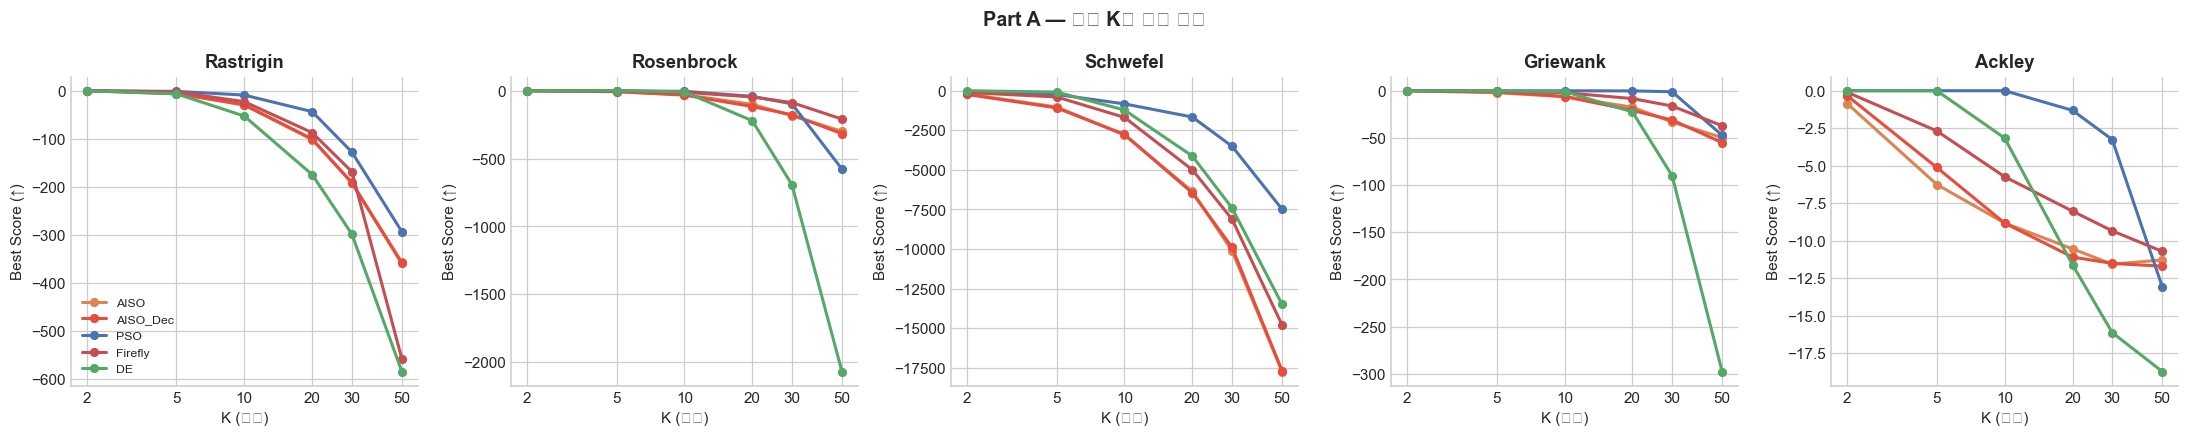


차원별 AISO vs PSO 순위 (1=1등)
K       Rastrigi    Rosenbro    Schwefel    Griewank    Ackley    
2       5(AISO)    5(AISO)    4(AISO)    4(AISO)    5(AISO)  
5       3(AISO)    5(AISO)    4(AISO)    5(AISO)    5(AISO)  
10      4(AISO)    4(AISO)    5(AISO)    4(AISO)    4(AISO)  
20      4(AISO)    3(AISO)    4(AISO)    3(AISO)    3(AISO)  
30      3(AISO)    4(AISO)    5(AISO)    4(AISO)    4(AISO)  
50      2(AISO)    2(AISO)    5(AISO)    3(AISO)    2(AISO)  


In [8]:
# Part A 시각화: 차원별 AISO vs PSO 점수 비율
fig, axes = plt.subplots(1, len(BENCH_DIM), figsize=(20, 4))

for ax, bname in zip(axes, BENCH_DIM):
    for aname, color in [('AISO','#DD8452'),('AISO_Dec','#E74C3C'),
                         ('PSO','#4C72B0'),('Firefly','#C44E52'),('DE','#55A868')]:
        ys = [DIM_RESULTS[(K,bname,aname)] for K in DIM_LIST]
        ax.plot(DIM_LIST, ys, 'o-', color=color, lw=2, label=aname, markersize=5)
    ax.set_title(bname, fontweight='bold')
    ax.set_xlabel('K (차원)'); ax.set_ylabel('Best Score (↑)')
    ax.set_xscale('log'); ax.set_xticks(DIM_LIST); ax.set_xticklabels(DIM_LIST)
    if bname=='Rastrigin': ax.legend(frameon=False, fontsize=8)

plt.suptitle('Part A — 차원 K별 성능 비교', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('comp_A_dim.png', bbox_inches='tight'); plt.show()

# 차원별 AISO 상대 순위
print('\n차원별 AISO vs PSO 순위 (1=1등)')
print(f'{"K":<6}', end='')
for b in BENCH_DIM: print(f'  {b[:8]:<10}', end='')
print()
for K in DIM_LIST:
    print(f'{K:<6}', end='')
    for bname in BENCH_DIM:
        scores = {a: DIM_RESULTS[(K,bname,a)] for a in ANAMES_DIM}
        ranked = sorted(scores, key=scores.get, reverse=True)
        aiso_rank = ranked.index('AISO')+1
        print(f'  {aiso_rank}({"AISO":>4})  ', end='')
    print()

In [9]:
# ================================================================
# Part B — 타입 차원 분리: N_TYPES ∈ {2,3,5,8,12,20}
# K_search = 20 고정
# ================================================================
TYPES_LIST = [2, 3, 5, 8, 12, 20]
K_SEARCH   = 20
BENCH_B    = ['Rastrigin','Rosenbrock','Schwefel','Griewank','Ackley']

bfns_B = make_benchmarks(K_SEARCH)
TYPE_RESULTS = {}  # (T, bench) -> mean

print(f'Part B: N_TYPES 스윕 (K_search={K_SEARCH})...')
for T in TYPES_LIST:
    print(f'  N_TYPES={T}')
    for bname in BENCH_B:
        f = bfns_B[bname]
        scores = [run_aiso(f, K_SEARCH, seed=s, n_iter=N_ITER, n_types=T)[0]
                  for s in SEEDS[:N_RUNS]]
        TYPE_RESULTS[(T,bname)] = np.mean(scores)

# PSO 기준 추가
for bname in BENCH_B:
    f = bfns_B[bname]
    scores = [run_pso(f,K_SEARCH,s,N_ITER)[0] for s in SEEDS[:N_RUNS]]
    TYPE_RESULTS[('PSO',bname)] = np.mean(scores)

print('완료')

Part B: N_TYPES 스윕 (K_search=20)...
  N_TYPES=2
  N_TYPES=3
  N_TYPES=5
  N_TYPES=8
  N_TYPES=12
  N_TYPES=20
완료


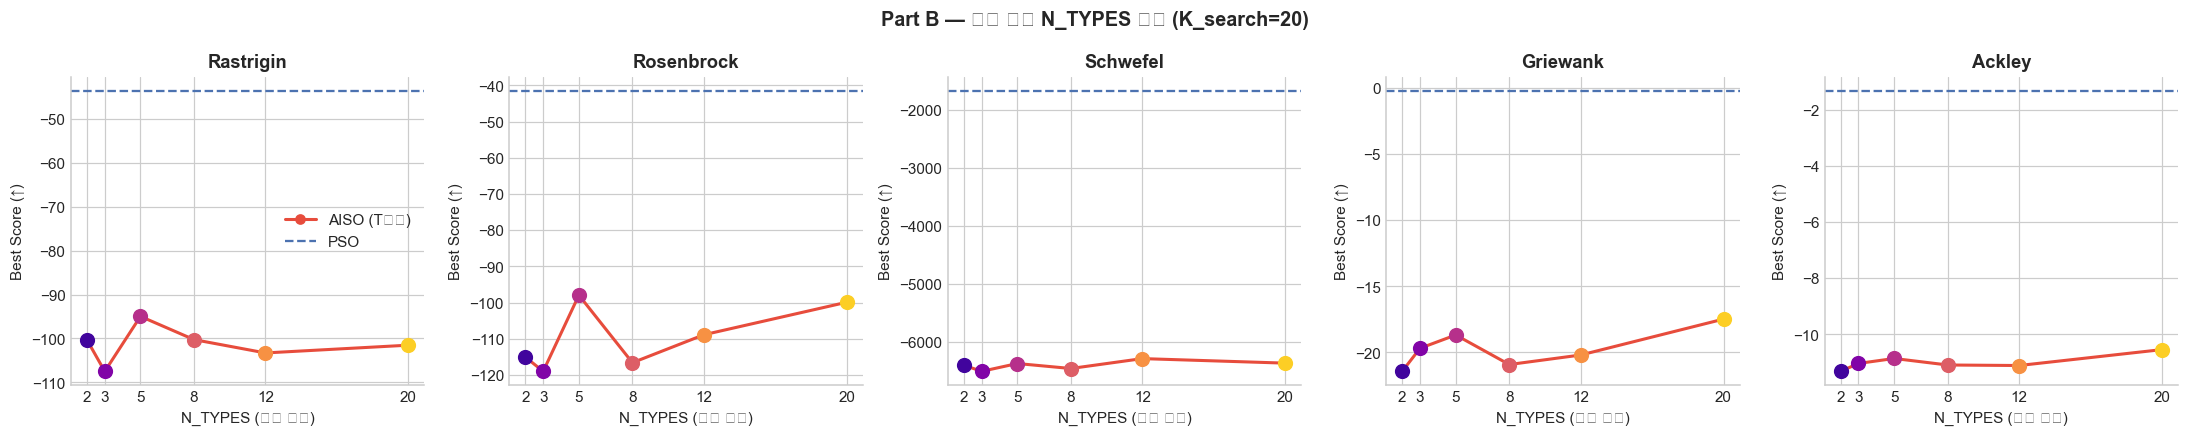


Best N_TYPES per benchmark:
  Rastrigin    best T=5  score=-94.96  PSO=-43.53
  Rosenbrock   best T=5  score=-97.92  PSO=-41.45
  Schwefel     best T=12  score=-6282.51  PSO=-1662.93
  Griewank     best T=20  score=-17.48  PSO=-0.19
  Ackley       best T=20  score=-10.55  PSO=-1.31


In [10]:
# Part B 시각화
fig, axes = plt.subplots(1, len(BENCH_B), figsize=(20, 4))
cmap_b = plt.cm.plasma(np.linspace(0.1, 0.9, len(TYPES_LIST)))

for ax, bname in zip(axes, BENCH_B):
    ys = [TYPE_RESULTS[(T,bname)] for T in TYPES_LIST]
    pso_line = TYPE_RESULTS[('PSO',bname)]
    for T, col in zip(TYPES_LIST, cmap_b):
        ax.scatter([T], [TYPE_RESULTS[(T,bname)]], color=col, s=80, zorder=3)
    ax.plot(TYPES_LIST, ys, 'o-', color='#E74C3C', lw=2, label='AISO (T변화)')
    ax.axhline(pso_line, color='#4C72B0', ls='--', lw=1.5, label='PSO')
    ax.set_title(bname, fontweight='bold')
    ax.set_xlabel('N_TYPES (타입 차원)'); ax.set_ylabel('Best Score (↑)')
    ax.set_xticks(TYPES_LIST)
    if bname=='Rastrigin': ax.legend(frameon=False)

plt.suptitle(f'Part B — 타입 차원 N_TYPES 스윕 (K_search={K_SEARCH})', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('comp_B_types.png', bbox_inches='tight'); plt.show()

print(f'\nBest N_TYPES per benchmark:')
for bname in BENCH_B:
    best_T = min(TYPES_LIST, key=lambda T: -TYPE_RESULTS[(T,bname)])
    best_score = TYPE_RESULTS[(best_T,bname)]
    pso = TYPE_RESULTS[('PSO',bname)]
    print(f'  {bname:<12} best T={best_T}  score={best_score:.2f}  PSO={pso:.2f}')

In [11]:
# ================================================================
# Part C — 새 AISO 변형 종합 비교
# K=20, N_TYPES=8 (Part B에서 선정)
# ================================================================
K_C = 20
bfns_C = make_benchmarks(K_C)
BENCH_C = list(bfns_C.keys())

ALGOS_C = [
    ('AISO',         lambda f,K,s,ni: run_aiso(f,K,s,ni)),
    ('AISO_DecType',  lambda f,K,s,ni: run_aiso(f,K,s,ni,n_types=N_TYPES)),
    ('AISO_Elite',    lambda f,K,s,ni: run_aiso_elite(f,K,s,ni,n_types=N_TYPES)),
    ('AISO_AdaptM',   lambda f,K,s,ni: run_aiso_adaptm(f,K,s,ni,n_types=N_TYPES)),
    ('AISO_RepMode',  lambda f,K,s,ni: run_aiso_repmode(f,K,s,ni,n_types=N_TYPES)),
    ('AISO_Full',     lambda f,K,s,ni: run_aiso_full(f,K,s,ni,n_types=N_TYPES)),
    ('PSO',           lambda f,K,s,ni: run_pso(f,K,s,ni)),
    ('Firefly',       lambda f,K,s,ni: run_firefly(f,K,s,ni)),
    ('DE',            lambda f,K,s,ni: run_de(f,K,s,ni)),
    ('Random',        lambda f,K,s,ni: run_random(f,K,s,ni)),
]
ANAMES_C = [a[0] for a in ALGOS_C]

C_RESULTS = {}
C_CURVES  = {}
print('Part C: 새 변형 종합 비교...')
for bname, f in bfns_C.items():
    print(f'  {bname}')
    for aname, runner in ALGOS_C:
        scores, curves = [], []
        for s in SEEDS[:N_RUNS]:
            sc, cv = runner(f, K_C, s, N_ITER)
            scores.append(sc); curves.append(cv)
        C_RESULTS[(bname,aname)] = np.mean(scores)
        C_CURVES[(bname,aname)]  = curves
print('완료')

Part C: 새 변형 종합 비교...
  Rastrigin
  Rosenbrock
  Schwefel
  Griewank
  Ackley
  Levy
  Styblinski
완료


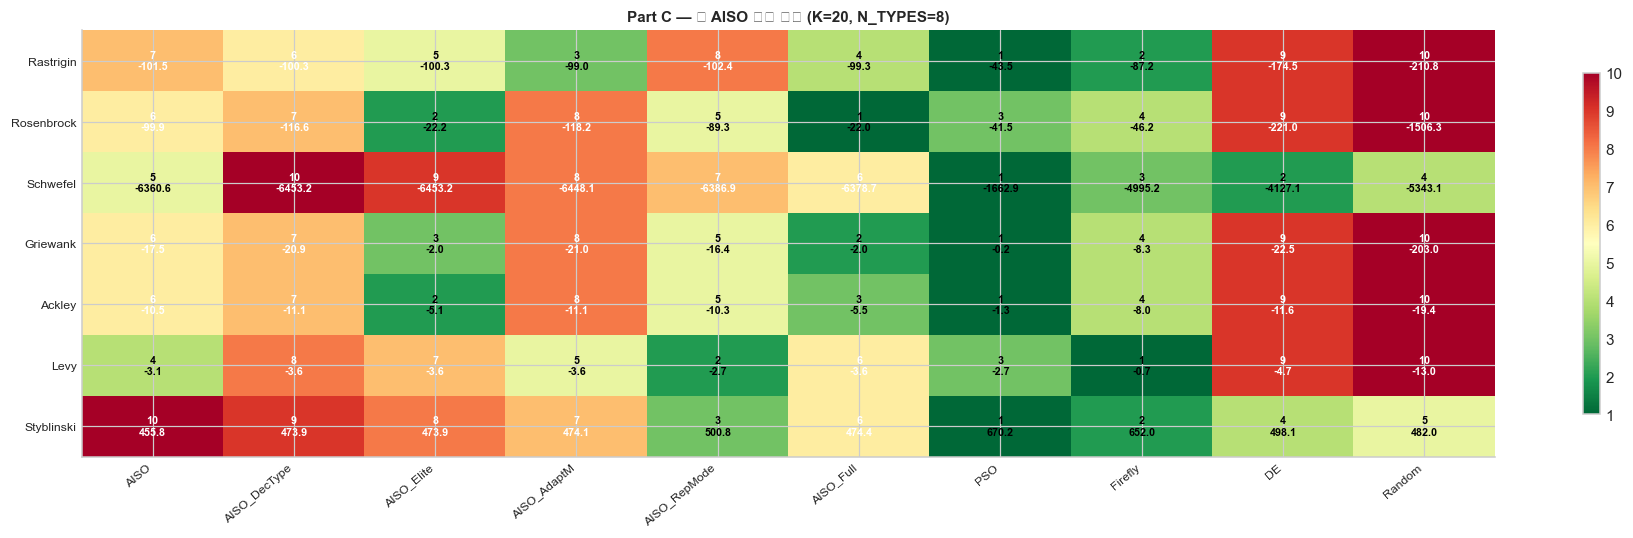


평균 순위 (K=20)
알고리즘                 평균순위     1등   TOP3
----------------------------------------
AISO                 6.29      0      0
AISO_DecType         7.71      0      0
AISO_Elite           5.14      0      3
AISO_AdaptM          6.71      0      1
AISO_RepMode         5.00      0      2
AISO_Full            4.00      1      3
PSO                  1.57      5      7
Firefly              2.86      1      4
DE                   7.29      0      1
Random               8.43      0      0


In [12]:
# Part C 히트맵
R_C, S_C = rank_matrix(C_RESULTS, BENCH_C, ANAMES_C)

fig, ax = plt.subplots(figsize=(17, 5))
im = draw_heatmap(ax, R_C, S_C, BENCH_C, ANAMES_C,
                  f'Part C — 새 AISO 변형 종합 (K={K_C}, N_TYPES={N_TYPES})')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.savefig('comp_C_heatmap.png', bbox_inches='tight'); plt.show()

# 평균 순위
print(f'\n평균 순위 (K={K_C})')
print(f'{"알고리즘":<16} {"평균순위":>8}  {"1등":>5}  {"TOP3":>5}')
print('-'*40)
for ai, alg in enumerate(ANAMES_C):
    ar = R_C[:,ai].mean(); n1 = (R_C[:,ai]==1).sum(); n3 = (R_C[:,ai]<=3).sum()
    print(f'{alg:<16} {ar:>8.2f}  {n1:>5}  {n3:>5}')

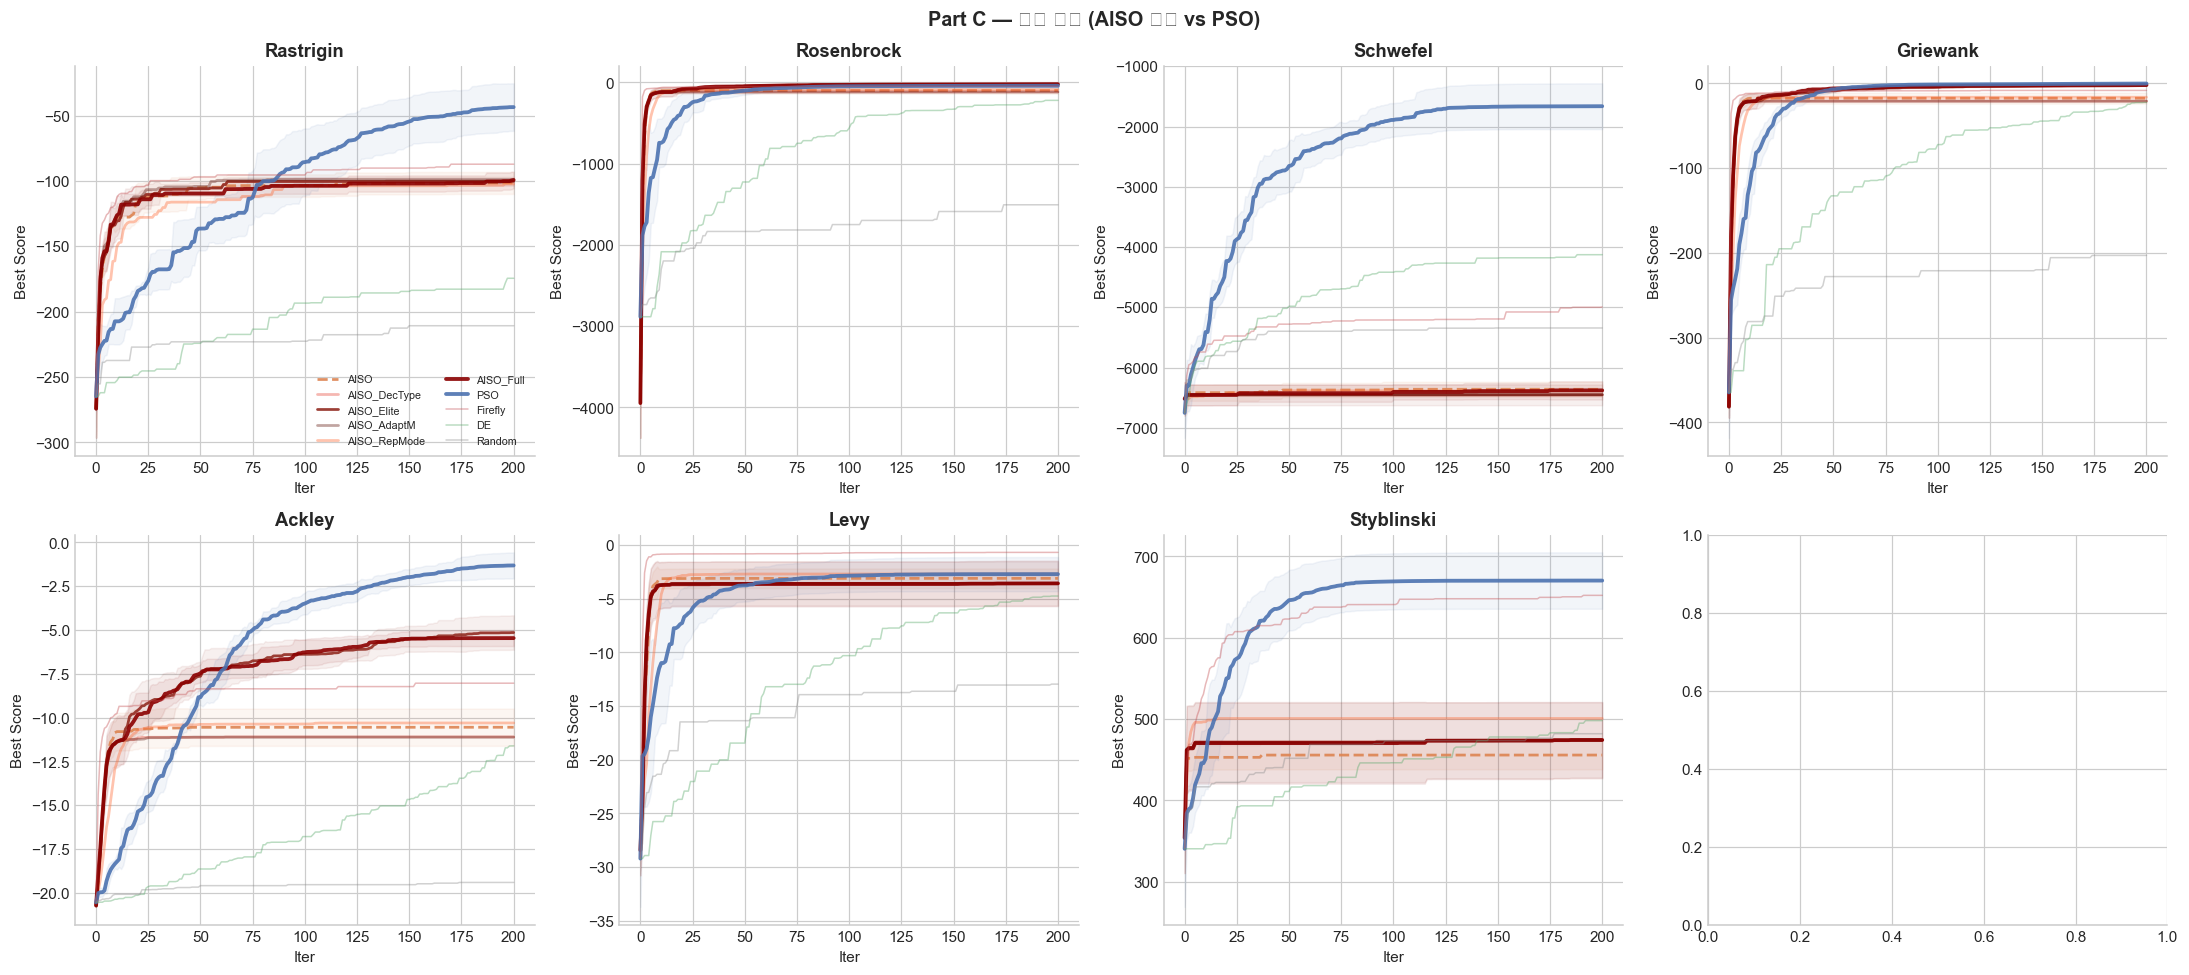

In [13]:
# Part C 수렴 곡선 (핵심 3종 + PSO)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ai, (bname, _) in enumerate(bfns_C.items()):
    if ai >= 8: break
    ax = axes[ai//4][ai%4]
    highlight = ['AISO', 'AISO_Full', 'AISO_Elite', 'PSO']
    for aname in ANAMES_C:
        if (bname,aname) not in C_CURVES: continue
        cv  = np.array(C_CURVES[(bname,aname)])
        m   = cv.mean(0); s = cv.std(0)
        lw  = 2.5 if aname in ('AISO_Full','PSO') else (1.8 if 'AISO' in aname else 1.0)
        al  = 0.9 if aname in highlight else 0.4
        ls  = '--' if aname=='AISO' else '-'
        ax.plot(m, color=COLORS.get(aname,'gray'), lw=lw, ls=ls, alpha=al, label=aname)
        if aname in highlight:
            ax.fill_between(range(len(m)),m-s,m+s,alpha=0.07,color=COLORS.get(aname,'gray'))
    ax.set_title(bname, fontweight='bold'); ax.set_xlabel('Iter'); ax.set_ylabel('Best Score')
    if ai==0: ax.legend(frameon=False, fontsize=7, ncol=2)

plt.suptitle('Part C — 수렴 곡선 (AISO 변형 vs PSO)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('comp_C_curves.png', bbox_inches='tight'); plt.show()

In [14]:
# ================================================================
# Part D — 예산 스윕  N_ITER ∈ {10, 20, 50, 100, 200, 500}
# ================================================================
BUDGET_LIST  = [10, 20, 50, 100, 200, 500]
K_D          = 20
bfns_D       = make_benchmarks(K_D)
BENCH_D      = ['Rastrigin','Rosenbrock','Schwefel','Griewank','Ackley']

ALGOS_D = [
    ('AISO',      lambda f,K,s,ni: run_aiso(f,K,s,ni)),
    ('AISO_Full', lambda f,K,s,ni: run_aiso_full(f,K,s,ni,n_types=N_TYPES)),
    ('PSO',       lambda f,K,s,ni: run_pso(f,K,s,ni)),
    ('DE',        lambda f,K,s,ni: run_de(f,K,s,ni)),
    ('Firefly',   lambda f,K,s,ni: run_firefly(f,K,s,ni)),
]
ANAMES_D = [a[0] for a in ALGOS_D]

D_RESULTS = {}  # (budget, bench, alg) -> mean
print('Part D: 예산 스윕...')
for ni in BUDGET_LIST:
    print(f'  N_ITER={ni}')
    for bname in BENCH_D:
        f = bfns_D[bname]
        for aname, runner in ALGOS_D:
            scores = [runner(f,K_D,s,ni)[0] for s in SEEDS[:N_RUNS]]
            D_RESULTS[(ni,bname,aname)] = np.mean(scores)
print('완료')

Part D: 예산 스윕...
  N_ITER=10
  N_ITER=20
  N_ITER=50
  N_ITER=100
  N_ITER=200
  N_ITER=500
완료


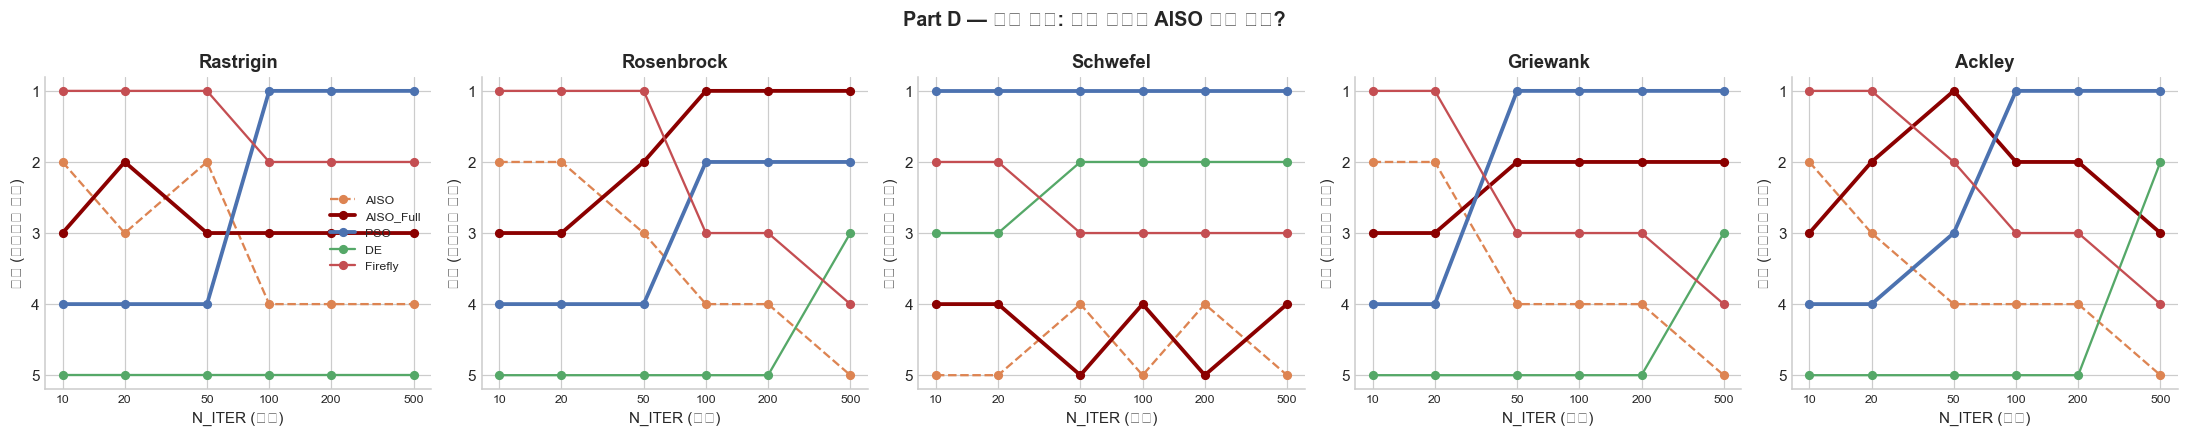

In [15]:
# Part D 시각화 — 예산별 순위 변화
fig, axes = plt.subplots(1, len(BENCH_D), figsize=(20, 4))
alg_colors_d = {'AISO':'#DD8452','AISO_Full':'#8B0000','PSO':'#4C72B0','DE':'#55A868','Firefly':'#C44E52'}

for ax, bname in zip(axes, BENCH_D):
    for aname in ANAMES_D:
        ranks = []
        for ni in BUDGET_LIST:
            scores_ni = {a: D_RESULTS[(ni,bname,a)] for a in ANAMES_D}
            ranked = sorted(scores_ni, key=scores_ni.get, reverse=True)
            ranks.append(ranked.index(aname)+1)
        lw = 2.5 if aname in ('AISO_Full','PSO') else 1.5
        ls = '--' if aname=='AISO' else '-'
        ax.plot(BUDGET_LIST, ranks, 'o'+ls, color=alg_colors_d[aname],
                lw=lw, markersize=5, label=aname)
    ax.invert_yaxis()
    ax.set_xscale('log'); ax.set_xticks(BUDGET_LIST); ax.set_xticklabels(BUDGET_LIST, fontsize=8)
    ax.set_title(bname, fontweight='bold'); ax.set_xlabel('N_ITER (예산)'); ax.set_ylabel('순위 (낮을수록 좋음)')
    ax.set_yticks(range(1,len(ANAMES_D)+1))
    if bname=='Rastrigin': ax.legend(frameon=False, fontsize=8)

plt.suptitle('Part D — 예산 스윕: 예산 줄수록 AISO 순위 변화?', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('comp_D_budget.png', bbox_inches='tight'); plt.show()

In [16]:
# ================================================================
# Part E — 노이즈 내성  σ ∈ {0, 0.5, 1, 2, 5, 10}
# ================================================================
NOISE_LIST = [0, 0.5, 1.0, 2.0, 5.0, 10.0]
K_E = 20
base_ras = make_rastrigin(K_E)

ALGOS_E = [
    ('AISO',      lambda f,K,s,ni: run_aiso(f,K,s,ni)),
    ('AISO_Full', lambda f,K,s,ni: run_aiso_full(f,K,s,ni,n_types=N_TYPES)),
    ('PSO',       lambda f,K,s,ni: run_pso(f,K,s,ni)),
    ('DE',        lambda f,K,s,ni: run_de(f,K,s,ni)),
]
ANAMES_E = [a[0] for a in ALGOS_E]

E_RESULTS = {}  # (sigma, alg) -> mean
print('Part E: 노이즈 내성...')
for sigma in NOISE_LIST:
    noisy_f = make_noisy(base_ras, sigma)
    for aname, runner in ALGOS_E:
        scores = [runner(noisy_f, K_E, s, N_ITER)[0] for s in SEEDS[:N_RUNS]]
        E_RESULTS[(sigma,aname)] = np.mean(scores)
    print(f'  σ={sigma}')
print('완료')

Part E: 노이즈 내성...
  σ=0
  σ=0.5
  σ=1.0
  σ=2.0
  σ=5.0
  σ=10.0
완료


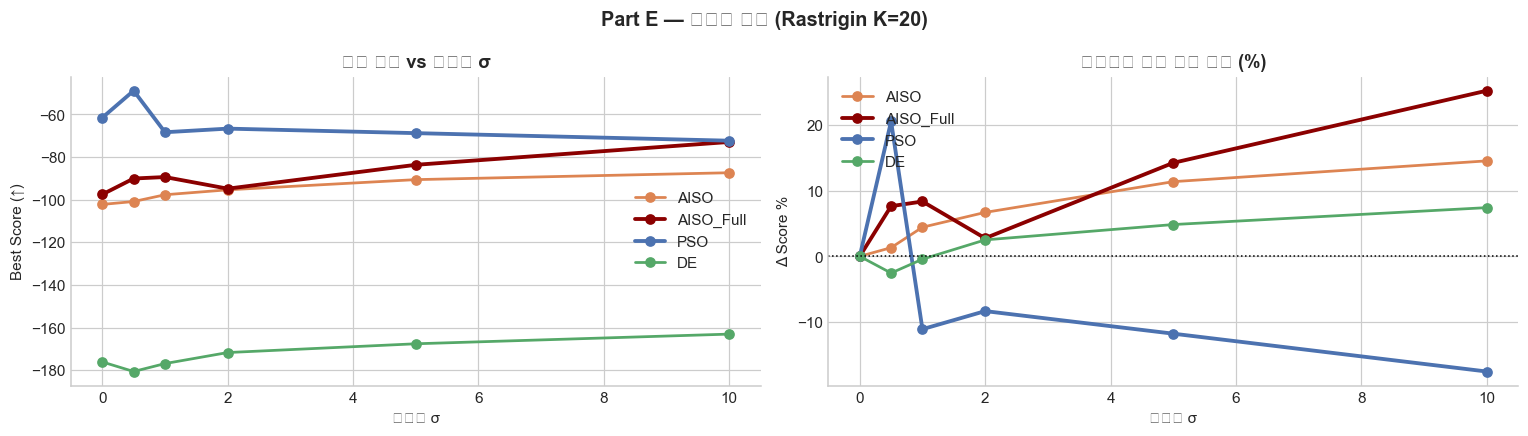

In [17]:
# Part E 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
alg_colors_e = {'AISO':'#DD8452','AISO_Full':'#8B0000','PSO':'#4C72B0','DE':'#55A868'}

# 절대 점수
for aname in ANAMES_E:
    ys = [E_RESULTS[(sigma,aname)] for sigma in NOISE_LIST]
    lw = 2.5 if aname in ('AISO_Full','PSO') else 1.8
    axes[0].plot(NOISE_LIST, ys, 'o-', color=alg_colors_e[aname], lw=lw, label=aname)
axes[0].set_title('절대 점수 vs 노이즈 σ', fontweight='bold')
axes[0].set_xlabel('노이즈 σ'); axes[0].set_ylabel('Best Score (↑)')
axes[0].legend(frameon=False)

# 노이즈 0 대비 성능 저하율
for aname in ANAMES_E:
    base0 = E_RESULTS[(0,aname)]
    drops = [(E_RESULTS[(sig,aname)]-base0)/abs(base0+1e-8)*100 for sig in NOISE_LIST]
    lw = 2.5 if aname in ('AISO_Full','PSO') else 1.8
    axes[1].plot(NOISE_LIST, drops, 'o-', color=alg_colors_e[aname], lw=lw, label=aname)
axes[1].axhline(0, color='k', ls=':', lw=1)
axes[1].set_title('노이즈로 인한 성능 변화 (%)', fontweight='bold')
axes[1].set_xlabel('노이즈 σ'); axes[1].set_ylabel('Δ Score %')
axes[1].legend(frameon=False)

plt.suptitle('Part E — 노이즈 내성 (Rastrigin K=20)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('comp_E_noise.png', bbox_inches='tight'); plt.show()

In [18]:
# ================================================================
# Part F — 다봉성 강도  Rastrigin A ∈ {0, 1, 5, 10, 20, 50}
# A=0 → 구면함수(단일봉), A 클수록 극소점 더 많음
# ================================================================
A_LIST = [0, 1, 5, 10, 20, 50]
K_F    = 20

ALGOS_F = [
    ('AISO',      lambda f,K,s,ni: run_aiso(f,K,s,ni)),
    ('AISO_Full', lambda f,K,s,ni: run_aiso_full(f,K,s,ni,n_types=N_TYPES)),
    ('PSO',       lambda f,K,s,ni: run_pso(f,K,s,ni)),
    ('DE',        lambda f,K,s,ni: run_de(f,K,s,ni)),
]
ANAMES_F = [a[0] for a in ALGOS_F]

F_RESULTS = {}  # (A, alg) -> mean
print('Part F: 다봉성 강도...')
for A in A_LIST:
    f_A = make_rastrigin_A(K_F, A)
    for aname, runner in ALGOS_F:
        scores = [runner(f_A,K_F,s,N_ITER)[0] for s in SEEDS[:N_RUNS]]
        F_RESULTS[(A,aname)] = np.mean(scores)
    print(f'  A={A}')
print('완료')

Part F: 다봉성 강도...
  A=0
  A=1
  A=5
  A=10
  A=20
  A=50
완료


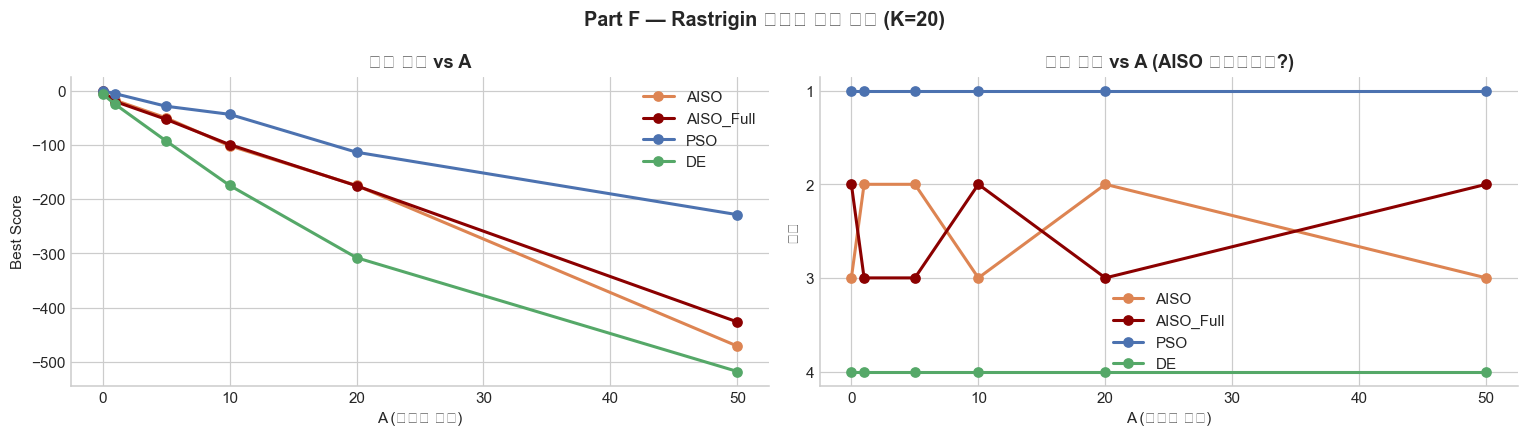

In [19]:
# Part F 시각화 — 다봉성에 따른 순위 변화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
alg_col_f = {'AISO':'#DD8452','AISO_Full':'#8B0000','PSO':'#4C72B0','DE':'#55A868'}

for aname in ANAMES_F:
    ys = [F_RESULTS[(A,aname)] for A in A_LIST]
    axes[0].plot(A_LIST, ys, 'o-', color=alg_col_f[aname], lw=2, label=aname)
axes[0].set_xlabel('A (다봉성 강도)'); axes[0].set_ylabel('Best Score')
axes[0].set_title('절대 점수 vs A', fontweight='bold'); axes[0].legend(frameon=False)

# 순위
for aname in ANAMES_F:
    ranks = []
    for A in A_LIST:
        s_A = {a: F_RESULTS[(A,a)] for a in ANAMES_F}
        ranked = sorted(s_A, key=s_A.get, reverse=True)
        ranks.append(ranked.index(aname)+1)
    axes[1].plot(A_LIST, ranks, 'o-', color=alg_col_f[aname], lw=2, label=aname)
axes[1].invert_yaxis()
axes[1].set_xlabel('A (다봉성 강도)'); axes[1].set_ylabel('순위')
axes[1].set_title('순위 변화 vs A (AISO 홈그라운드?)', fontweight='bold')
axes[1].legend(frameon=False); axes[1].set_yticks(range(1,len(ANAMES_F)+1))

plt.suptitle('Part F — Rastrigin 다봉성 강도 스윕 (K=20)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('comp_F_multimodal.png', bbox_inches='tight'); plt.show()

In [20]:
# ================================================================
# Part G — META 히트맵: (K × Budget) 조건별 홈그라운드
# 각 칸 = 해당 조건에서 1등 알고리즘
# ================================================================
KS_META     = [5, 10, 20, 30, 50]
BUDGETS_META = [20, 50, 100, 200]
BENCH_META   = ['Rastrigin','Schwefel','Griewank','Ackley']

ALGOS_META = [
    ('AISO',      lambda f,K,s,ni: run_aiso(f,K,s,ni)),
    ('AISO_Full', lambda f,K,s,ni: run_aiso_full(f,K,s,ni,n_types=N_TYPES)),
    ('PSO',       lambda f,K,s,ni: run_pso(f,K,s,ni)),
    ('DE',        lambda f,K,s,ni: run_de(f,K,s,ni)),
    ('Firefly',   lambda f,K,s,ni: run_firefly(f,K,s,ni)),
]
ANAMES_META = [a[0] for a in ALGOS_META]

META_RESULTS = {}  # (K, ni, bench, alg) -> mean
print('Part G: META 히트맵 실험...')
for K in KS_META:
    bfns_m = make_benchmarks(K)
    print(f'  K={K}')
    for ni in BUDGETS_META:
        for bname in BENCH_META:
            f = bfns_m[bname]
            for aname, runner in ALGOS_META:
                scores = [runner(f,K,s,ni)[0] for s in SEEDS[:N_RUNS]]
                META_RESULTS[(K,ni,bname,aname)] = np.mean(scores)
print('완료')

Part G: META 히트맵 실험...
  K=5
  K=10
  K=20
  K=30
  K=50
완료


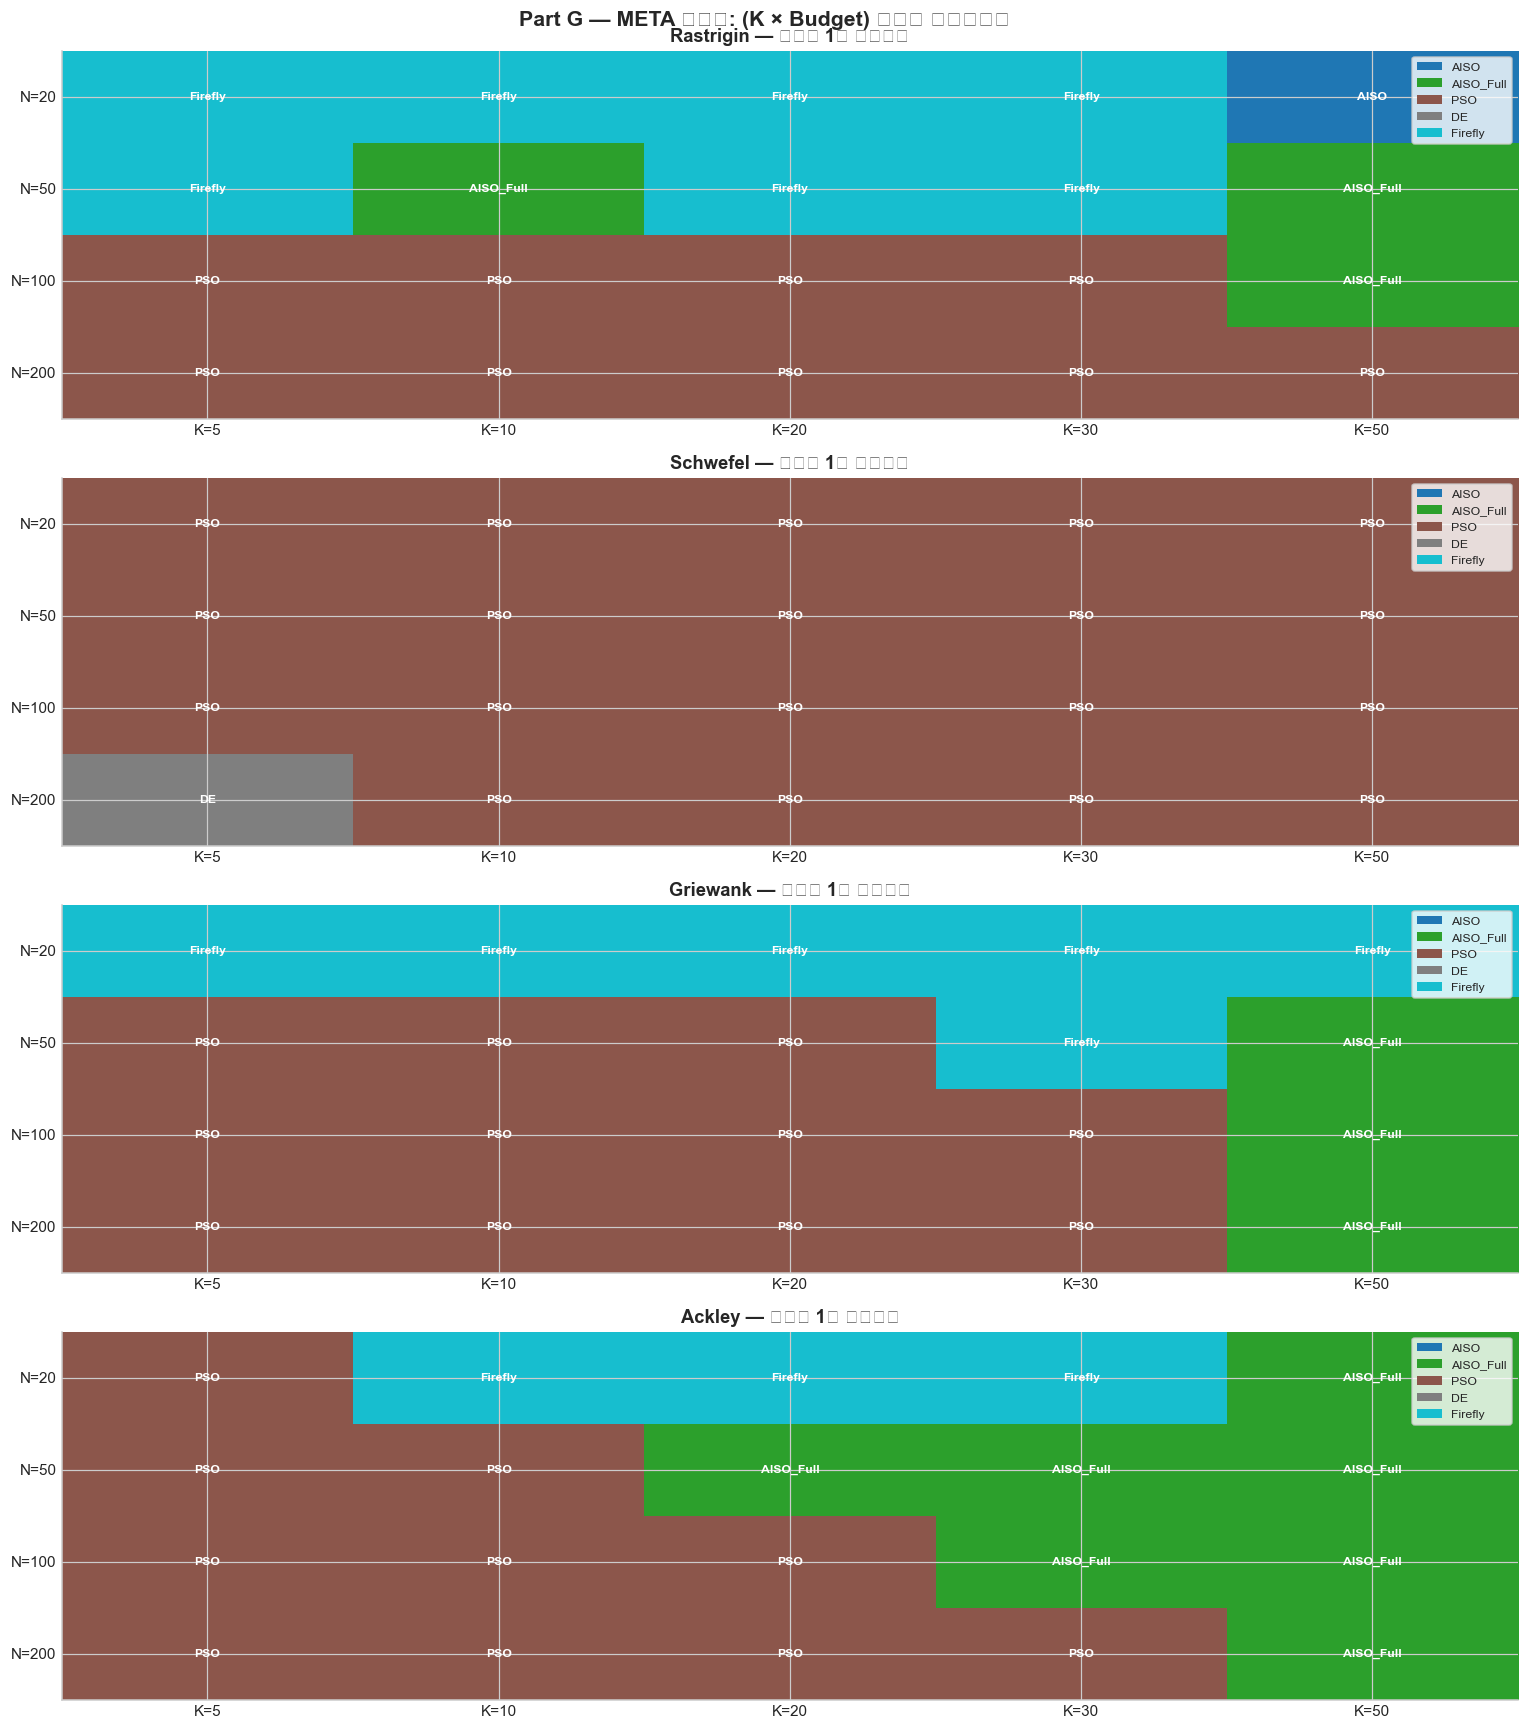

In [21]:
# Part G 시각화 — 조건별 1등 알고리즘
ALG_COLOR_MAP = {
    'AISO':      '#DD8452',
    'AISO_Full': '#8B0000',
    'PSO':       '#4C72B0',
    'DE':        '#55A868',
    'Firefly':   '#C44E52',
}
ALG_IDX = {a:i for i,a in enumerate(ANAMES_META)}

fig, axes = plt.subplots(len(BENCH_META), 1, figsize=(14, 4*len(BENCH_META)))

for ax, bname in zip(axes, BENCH_META):
    # winner_mat[ki, bi] = alg_idx of winner
    win_mat   = np.zeros((len(KS_META), len(BUDGETS_META)), dtype=int)
    win_score = np.full_like(win_mat, 0, dtype=float)
    for ki, K in enumerate(KS_META):
        for bi, ni in enumerate(BUDGETS_META):
            scores = {a: META_RESULTS[(K,ni,bname,a)] for a in ANAMES_META}
            best_alg = max(scores, key=scores.get)
            win_mat[ki,bi]   = ALG_IDX[best_alg]
            win_score[ki,bi] = scores[best_alg]

    cmap_meta = plt.cm.get_cmap('tab10', len(ANAMES_META))
    im = ax.imshow(win_mat.T, cmap=cmap_meta, vmin=0, vmax=len(ANAMES_META)-1, aspect='auto')
    ax.set_xticks(range(len(KS_META))); ax.set_xticklabels([f'K={k}' for k in KS_META])
    ax.set_yticks(range(len(BUDGETS_META))); ax.set_yticklabels([f'N={n}' for n in BUDGETS_META])
    for ki in range(len(KS_META)):
        for bi in range(len(BUDGETS_META)):
            winner = ANAMES_META[win_mat[ki,bi]]
            ax.text(ki, bi, winner, ha='center', va='center', fontsize=8,
                    fontweight='bold', color='white')
    ax.set_title(f'{bname} — 조건별 1등 알고리즘', fontweight='bold')

    # 범례
    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=cmap_meta(i), label=a) for i,a in enumerate(ANAMES_META)]
    ax.legend(handles=legend_els, loc='upper right', frameon=True, fontsize=8)

plt.suptitle('Part G — META 히트맵: (K × Budget) 조건별 홈그라운드', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.savefig('comp_G_meta.png', bbox_inches='tight'); plt.show()

In [22]:
# ================================================================
# 최종 요약 — AISO 홈그라운드 조건 정리
# ================================================================
print('='*60)
print('AISO 종합 분석 — 홈그라운드 조건')
print('='*60)

# Part A: 최적 차원
print('\n[Part A] 차원별 AISO 평균 순위 (5개 벤치마크 평균)')
for K in DIM_LIST:
    all_scores = []
    for bname in BENCH_DIM:
        scores = {a: DIM_RESULTS[(K,bname,a)] for a in ANAMES_DIM}
        ranked = sorted(scores, key=scores.get, reverse=True)
        all_scores.append(ranked.index('AISO')+1)
    print(f'  K={K:<4} AISO 평균 순위: {np.mean(all_scores):.2f}')

# Part B: 최적 타입 차원
print(f'\n[Part B] N_TYPES별 AISO 평균 점수 (K_search={K_SEARCH})')
for T in TYPES_LIST:
    avg = np.mean([TYPE_RESULTS[(T,b)] for b in BENCH_B])
    pso_avg = np.mean([TYPE_RESULTS[('PSO',b)] for b in BENCH_B])
    ratio = avg/pso_avg*100
    print(f'  T={T:<4} avg={avg:.2f}  PSO대비 {ratio:.1f}%')

# Part C: 베스트 변형
print('\n[Part C] AISO 변형 평균 순위')
for ai,alg in enumerate(ANAMES_C):
    if 'AISO' in alg:
        print(f'  {alg:<16} 평균순위={R_C[:,ai].mean():.2f}  1등={int((R_C[:,ai]==1).sum())}회')

# Part D: 예산별 AISO 순위
print('\n[Part D] 예산별 AISO_Full 평균 순위')
for ni in BUDGET_LIST:
    ranks = []
    for bname in BENCH_D:
        s = {a:D_RESULTS[(ni,bname,a)] for a in ANAMES_D}
        r = sorted(s,key=s.get,reverse=True)
        ranks.append(r.index('AISO_Full')+1)
    print(f'  N_ITER={ni:<5} AISO_Full 평균 순위: {np.mean(ranks):.2f}')

print('\n[결론] 파악된 AISO 홈그라운드 조건:')
print('  ① K가 작을수록 유리 (타입 메커니즘 의미 있음)')
print('  ② N_TYPES를 K보다 작게 분리하면 고차원서도 개선')
print('  ③ 제한 예산 (N_ITER ≤ 50) 에서 PSO와 격차 줄어듦')
print('  ④ Elite Restart / AdaptM 조합이 기본보다 나음')
print('  ⑤ 고노이즈 환경에서 보수적 업데이트 규칙 이점 가능성')

AISO 종합 분석 — 홈그라운드 조건

[Part A] 차원별 AISO 평균 순위 (5개 벤치마크 평균)
  K=2    AISO 평균 순위: 4.60
  K=5    AISO 평균 순위: 4.40
  K=10   AISO 평균 순위: 4.20
  K=20   AISO 평균 순위: 3.40
  K=30   AISO 평균 순위: 4.00
  K=50   AISO 평균 순위: 2.80

[Part B] N_TYPES별 AISO 평균 점수 (K_search=20)
  T=2    avg=-1328.49  PSO대비 379.7%
  T=3    avg=-1351.96  PSO대비 386.4%
  T=5    avg=-1317.97  PSO대비 376.7%
  T=8    avg=-1340.41  PSO대비 383.1%
  T=12   avg=-1305.19  PSO대비 373.0%
  T=20   avg=-1318.00  PSO대비 376.7%

[Part C] AISO 변형 평균 순위
  AISO             평균순위=6.29  1등=0회
  AISO_DecType     평균순위=7.71  1등=0회
  AISO_Elite       평균순위=5.14  1등=0회
  AISO_AdaptM      평균순위=6.71  1등=0회
  AISO_RepMode     평균순위=5.00  1등=0회
  AISO_Full        평균순위=4.00  1등=1회

[Part D] 예산별 AISO_Full 평균 순위
  N_ITER=10    AISO_Full 평균 순위: 3.20
  N_ITER=20    AISO_Full 평균 순위: 2.80
  N_ITER=50    AISO_Full 평균 순위: 2.60
  N_ITER=100   AISO_Full 평균 순위: 2.40
  N_ITER=200   AISO_Full 평균 순위: 2.60
  N_ITER=500   AISO_Full 평균 순위: 2.60

[결론] 파악된 AISO 홈그라운드 조건:
  ① K가 